# Imports
In this section, we install and import all necessary libraries for data manipulation, visualization, preprocessing, and machine learning, including TensorFlow and Scikeras for neural networks.

###Libraries

In [ ]:
!pip install numpy pandas scikit-learn tensorflow scikeras
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import PowerTransformer
from scikeras.wrappers import KerasClassifier
from google.colab import drive
from sklearn.utils import resample
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import SelectKBest, f_classif

### Drive Mounting & Data Loading
We load the water potability dataset into a pandas DataFrame to begin our analysis. This dataset contains water quality metrics for 3276 different water bodies.

In [ ]:
df = pd.read_csv('/content/water_potability.csv')


# Data Preprocessing
This phase involves cleaning and transforming the raw data to make it suitable for machine learning models. We focus on handling missing values, addressing skewness, and scaling features.

### Data Info
Initial inspection of the dataset's shape, data types, and statistical summary to understand the range and distribution of the features.

In [ ]:
print("Dataset shape:", df.shape)
print(df.dtypes)
df.describe()

Dataset shape: (3276, 10)
ph                 float64
Hardness           float64
Solids             float64
Chloramines        float64
Sulfate            float64
Conductivity       float64
Organic_carbon     float64
Trihalomethanes    float64
Turbidity          float64
Potability           int64
dtype: object


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


### Data Distribution & Skewness
Visualizing feature distributions helps identify skewed data. Some features like 'Solids' show significant skewness, which might require power transformations for certain algorithms.

Some features (like Solids) are skewed

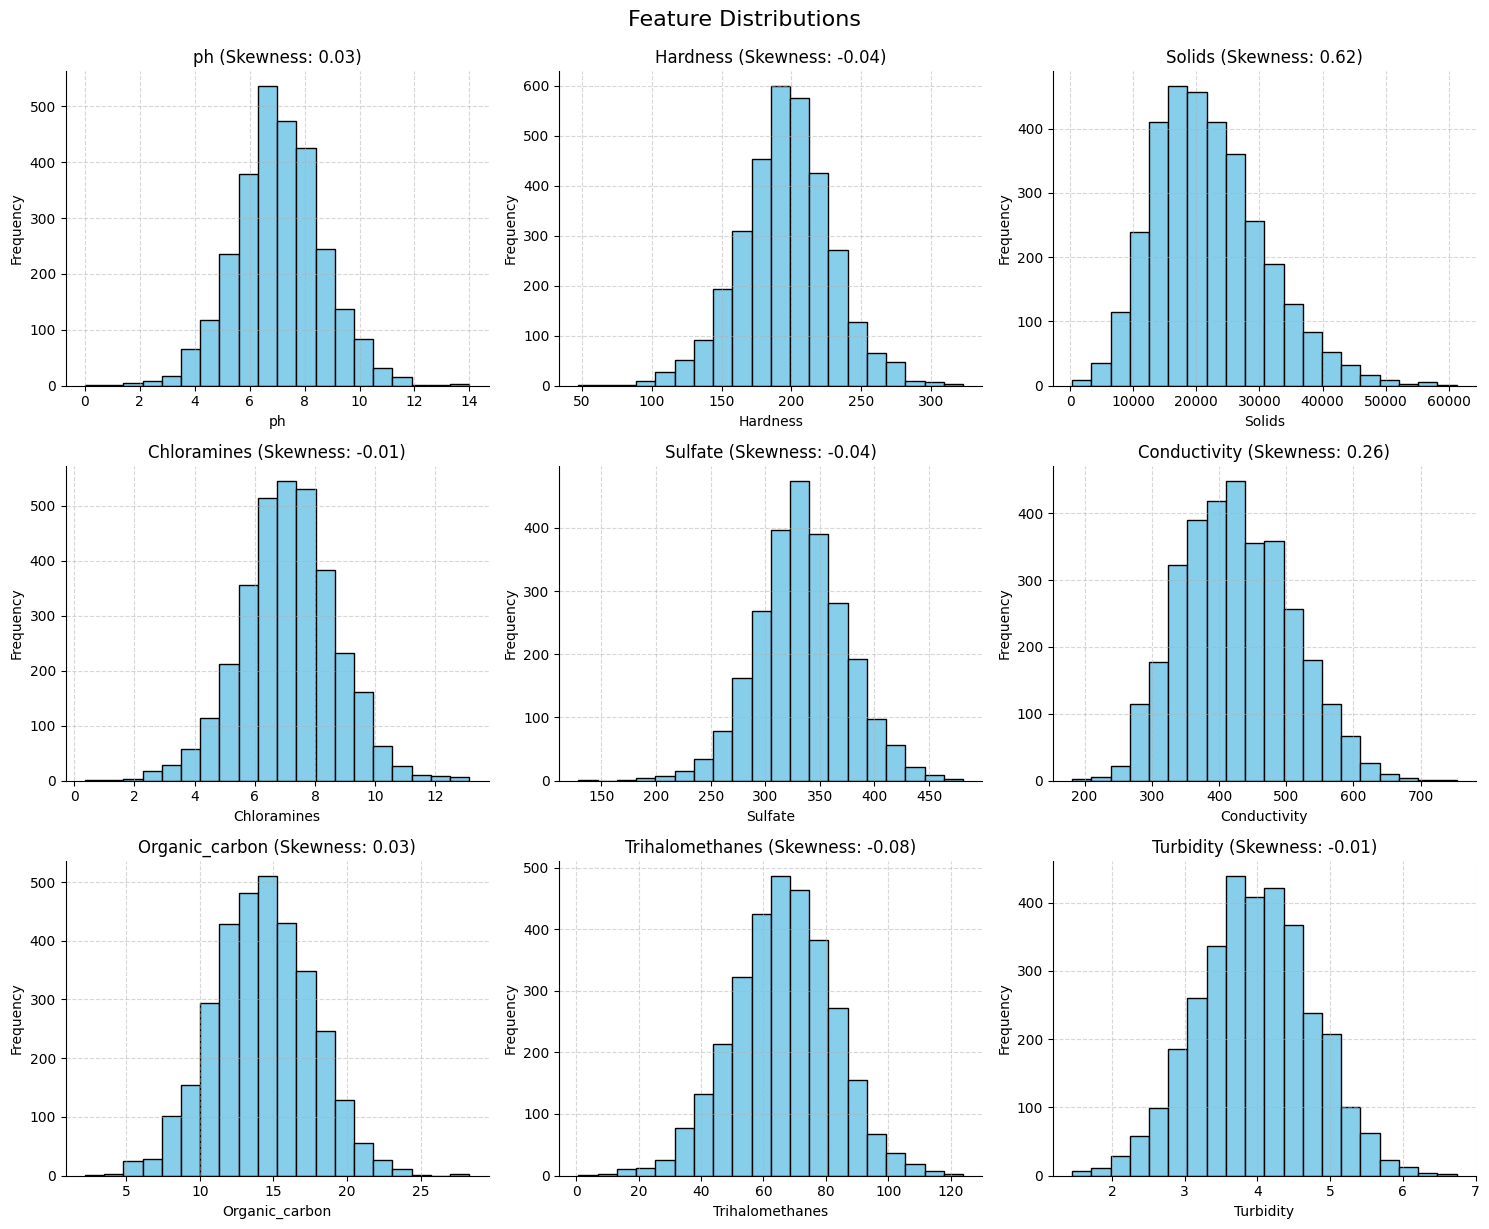

In [ ]:
# Drop the target column
feature_cols = df.drop('Potability', axis=1).columns

skew_values = df[feature_cols].skew()

# Set up the grid
plt.figure(figsize=(15, 12))
for i, col in enumerate(feature_cols, 1):
    plt.subplot(3, 3, i)  # 3x3 grid for 9 features
    df[col].plot(kind='hist', bins=20, edgecolor='black', color='skyblue')
    plt.title(col + f' (Skewness: {skew_values[col]:.2f})')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.gca().spines[['top', 'right']].set_visible(False)
    plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.suptitle('Feature Distributions', fontsize=16, y=1.02)
plt.show()

### Correlation Heatmap
We use a heatmap to visualize the Pearson correlation coefficients between features. This helps identify multicollinearity and understand how features relate to the target 'Potability' variable.

<Axes: >

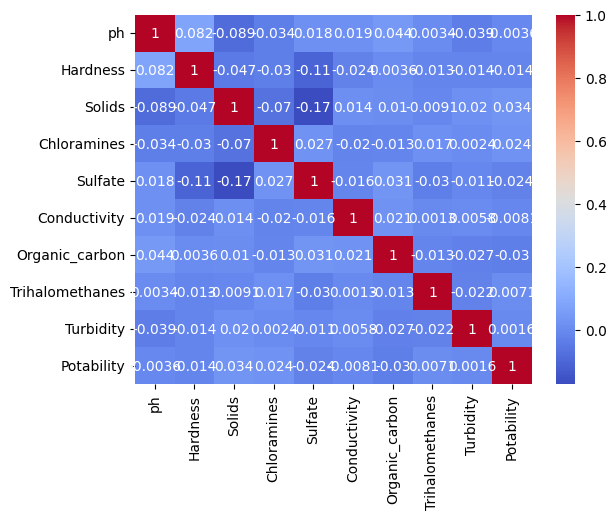

In [ ]:
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')

### Missing Values
We have almost 1400 empty entries which accounts for almost 40% of the dataset.
Thus, this data cannot be removed and should be estimated. I used the KNN imputation method instead of mean or median imputation to avoid introducing a large number of identical values in features, which could distort the distribution and reduce model performance.

In [ ]:
from sklearn.impute import KNNImputer

print(df.isnull().sum())
print('Total Missing Values (Before):' , df.isnull().sum().sum())

# Impute missing values using KNN
imputer = KNNImputer(n_neighbors=7, weights='distance')
df = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

print('Total Missing Values (After):' , df.isnull().sum().sum())
df



ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64
Total Missing Values (Before): 1434
Total Missing Values (After): 0


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,6.760807,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0.0
1,3.716080,129.422921,18630.057858,6.635246,336.890827,592.885359,15.180013,56.329076,4.500656,0.0
2,8.099124,224.236259,19909.541732,9.275884,329.370307,418.606213,16.868637,66.420093,3.055934,0.0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0.0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0.0
...,...,...,...,...,...,...,...,...,...,...
3271,4.668102,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1.0
3272,7.808856,193.553212,17329.802160,8.061362,346.511627,392.449580,19.903225,62.989957,2.798243,1.0
3273,9.419510,175.762646,33155.578218,7.350233,323.103785,432.044783,11.039070,69.845400,3.298875,1.0
3274,5.126763,230.603758,11983.869376,6.303357,333.624378,402.883113,11.168946,77.488213,4.708658,1.0


In [ ]:
# KMeansClustering - delete outlier
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(df)
labels = kmeans.labels_
df_kmeans = df[labels == 1]
df_kmeans.reset_index(inplace = True)
df_kmeans
import pandas as pd




### Data Splitting
Before training, we separate our features (X) from the target (y) and split the data into training and testing sets. This ensures we can evaluate our models on unseen data to check for overfitting.

In [ ]:
# Feature and target split
X = df_kmeans.drop('Potability', axis=1)
y = df_kmeans['Potability']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)


In [ ]:
pip install scikeras


### Model Tuning & Evaluation
We evaluate multiple classifiers including KNN, Logistic Regression, SVM, Decision Trees, XGBoost, and a Neural Network. We apply StandardScaler and SMOTE to the training data to handle feature scales and class imbalance effectively.


===== K-Nearest Neighbors =====
Training Accuracy: 1.0000
Test Accuracy: 0.6507

Classification Report (Test):
              precision    recall  f1-score   support

         0.0       0.65      0.85      0.74       214
         1.0       0.66      0.39      0.49       161

    accuracy                           0.65       375
   macro avg       0.65      0.62      0.61       375
weighted avg       0.65      0.65      0.63       375


===== Logistic Regression =====
Training Accuracy: 0.6163
Test Accuracy: 0.6000

Classification Report (Test):
              precision    recall  f1-score   support

         0.0       0.67      0.58      0.62       214
         1.0       0.53      0.63      0.57       161

    accuracy                           0.60       375
   macro avg       0.60      0.60      0.60       375
weighted avg       0.61      0.60      0.60       375


===== Support Vector Machine =====
Training Accuracy: 0.8121
Test Accuracy: 0.6693

Classification Report (Test):
       

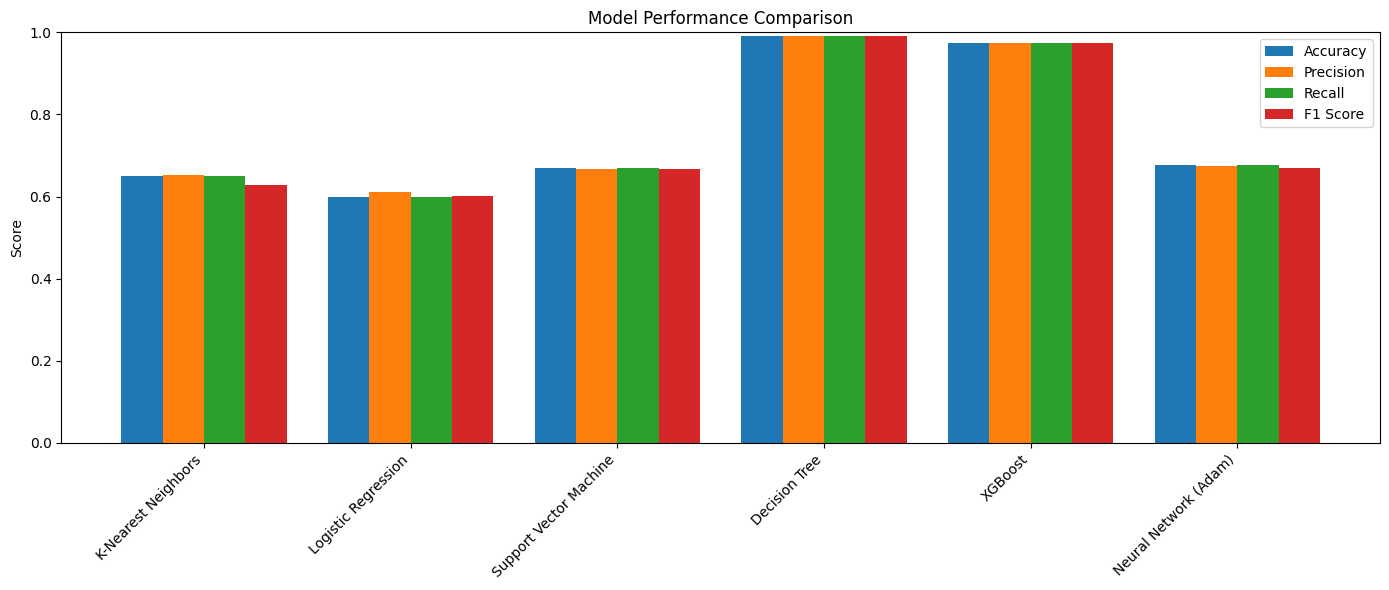

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from scikeras.wrappers import KerasClassifier
from tensorflow.keras import Input

# -- Preprocessing --
sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train)
X_test_sc = sc.transform(X_test)

# Apply SMOTE on training data only
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_sc, y_train)


models = {
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=7, metric='euclidean', weights='distance'),
    'Logistic Regression': LogisticRegression(C=0.1, penalty='l2', solver='lbfgs', class_weight='balanced', max_iter=1000),
    'Support Vector Machine': SVC(C=1, kernel='rbf', gamma='scale', class_weight='balanced', probability=True),
    'Decision Tree': DecisionTreeClassifier(max_depth=15, class_weight='balanced', criterion='entropy', random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, max_depth=7, learning_rate=0.2, scale_pos_weight=1.5, eval_metric='logloss', random_state=42)
}

metrics = {
    'Model': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1 Score': []
}




for name, model in models.items():
    print(f"\n===== {name} =====")

    model.fit(X_train_sc, y_train)
    y_train_pred = model.predict(X_train_sc)
    y_test_pred = model.predict(X_test_sc)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    print(f"Training Accuracy: {train_acc:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")

    print("\nClassification Report (Test):")
    report = classification_report(y_test, y_test_pred, zero_division=0)
    print(report)

    report_dict = classification_report(y_test, y_test_pred, output_dict=True, zero_division=0)
    metrics['Model'].append(name)
    metrics['Accuracy'].append(test_acc)
    metrics['Precision'].append(report_dict['weighted avg']['precision'])
    metrics['Recall'].append(report_dict['weighted avg']['recall'])
    metrics['F1 Score'].append(report_dict['weighted avg']['f1-score'])

# Neural network model definition
def create_model(optimizer='adam'):
    model = Sequential()
    model.add(Input(shape=(X_train_sc.shape[1],)))
    model.add(Dense(12, activation='relu'))
    model.add(Dense(8, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    return model

print("\n===== Neural Network (Adam optimizer) =====")
nn_model = KerasClassifier(model=create_model, epochs=75, batch_size=10, optimizer='adam', verbose=0)
nn_model.fit(X_train_sc, y_train)
y_train_pred_nn = nn_model.predict(X_train_sc)
y_test_pred_nn = nn_model.predict(X_test_sc)

train_acc_nn = accuracy_score(y_train, y_train_pred_nn)
test_acc_nn = accuracy_score(y_test, y_test_pred_nn)

print(f"Training Accuracy: {train_acc_nn:.4f}")
print(f"Test Accuracy: {test_acc_nn:.4f}")

print("\nClassification Report (Test):")
report_nn = classification_report(y_test, y_test_pred_nn, zero_division=0)
print(report_nn)

report_dict_nn = classification_report(y_test, y_test_pred_nn, output_dict=True, zero_division=0)
metrics['Model'].append('Neural Network (Adam)')
metrics['Accuracy'].append(test_acc_nn)
metrics['Precision'].append(report_dict_nn['weighted avg']['precision'])
metrics['Recall'].append(report_dict_nn['weighted avg']['recall'])
metrics['F1 Score'].append(report_dict_nn['weighted avg']['f1-score'])

# Plot performance comparison
labels = metrics['Model']
x = np.arange(len(labels))
width = 0.2

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - 1.5*width, metrics['Accuracy'], width, label='Accuracy')
ax.bar(x - 0.5*width, metrics['Precision'], width, label='Precision')
ax.bar(x + 0.5*width, metrics['Recall'], width, label='Recall')
ax.bar(x + 1.5*width, metrics['F1 Score'], width, label='F1 Score')

ax.set_ylim(0, 1)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.legend()

plt.tight_layout()
plt.show()
